# 05 — Integración: Contratos Electrónicos + Adiciones

**Objetivo**: Cruzar la fuente madre (`contratosElectronicos`) con las adiciones para
entender el comportamiento de los contratos de Obra: extensiones de plazo, adiciones
en valor, suspensiones, cesiones y su relación con variables contractuales.

**JOIN**: `contratosElectronicos.id_contrato` ← LEFT JOIN → `adiciones.id_contrato`

---

**Por qué este notebook existe y dónde se ubica en el flujo del proyecto.** Los notebooks anteriores (01 a 04) exploraron cada fuente de SECOP II por separado: contratos electrónicos, procesos de selección, adiciones/eventos de modificación y proveedores. Cada una de esas fuentes vive en su propio archivo Parquet, con su propia llave y su propia granularidad (por ejemplo, `contratosElectronicos` tiene una fila por contrato, mientras que `adiciones` tiene una fila por *evento* de modificación, es decir, puede haber varias filas para un mismo contrato). Este notebook es el punto donde esas fuentes dejan de vivir por separado: se limpian, se deduplican, se agregan a la granularidad correcta y se unen (`merge`) en una sola tabla ancha. El resultado — 48.331 contratos de Obra Pública con más de cien columnas — es el archivo central (`contratos_adiciones_obra.parquet`) del que parten, de manera independiente, tanto el análisis predictivo del compañero de tesis como el análisis descriptivo de este documento. Por eso cualquier decisión metodológica tomada aquí (qué se deduplica, cómo se resuelven duplicados, qué tipo de `JOIN` se usa, cómo se agregan las adiciones) se propaga a todo el trabajo posterior.

**Por qué un LEFT JOIN y no un INNER JOIN.** La tabla de contratos electrónicos es la *fuente madre*: representa el universo completo de contratos de obra que se quiere estudiar, tengan o no modificaciones posteriores. Si se usara un `INNER JOIN` contra la tabla de adiciones, se perderían todos los contratos que nunca tuvieron una modificación registrada (como se ve más adelante, son 14.866 de los 48.331, un 30.8%), y el análisis quedaría sesgado hacia contratos "problemáticos". El `LEFT JOIN` conserva el universo completo, dejando en `NaN` (posteriormente convertido a 0) los contadores de modificación de los contratos que nunca fueron adicionados, lo cual es la representación correcta: "cero eventos" y no "dato faltante".

## 1. Configuración y carga de datos

Se importan las librerías estándar de análisis (`pandas`, `numpy`) y de visualización (`matplotlib`, `seaborn`), se silencian warnings no críticos y se fijan opciones de despliegue (mostrar todas las columnas, ancho de columna, tamaño de figura) para que las tablas intermedias de este notebook —que llegan a tener más de cien columnas— se puedan inspeccionar sin truncarse. `DATA_DIR` apunta a la carpeta compartida `../data/` donde los notebooks anteriores (01 y 03) ya dejaron guardados, en formato Parquet, los archivos `contratos_electronicos_obra.parquet` (51.353 filas × 87 columnas) y `adiciones_obra.parquet` (249.037 filas × 5 columnas). Se usa Parquet en vez de CSV en todo el proyecto porque conserva los tipos de dato entre notebooks (evita volver a inferir fechas y numéricos cada vez) y porque su compresión columnar reduce sustancialmente el tamaño en disco para tablas de este volumen.

La celda siguiente carga ambos archivos y confirma sus dimensiones antes de cualquier limpieza: 51.353 contratos y 249.037 eventos de adición. Estas dos cifras son el punto de partida de todas las cuentas de deduplicación que siguen en la sección 2.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 80)
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

DATA_DIR = '../data/'
print('Configuración lista.')

Configuración lista.


In [2]:
# Cargar fuentes
df_contratos = pd.read_parquet(DATA_DIR + 'contratos_electronicos_obra.parquet')
df_adiciones = pd.read_parquet(DATA_DIR + 'adiciones_obra.parquet')

print(f'Contratos: {df_contratos.shape}')
print(f'Adiciones: {df_adiciones.shape}')

Contratos: (51353, 87)
Adiciones: (249037, 5)


## 2. Limpieza previa

Deduplicar ambas fuentes y convertir tipos antes del join.

**Por qué deduplicar antes de unir y no después.** Si se uniera primero y se deduplicara después, un contrato duplicado se multiplicaría por cada una de sus copias durante el `merge`, generando combinaciones espurias (producto cartesiano parcial) difíciles de detectar y de deshacer. Por eso la deduplicación de ambas fuentes ocurre *antes* del `JOIN` de la sección 4, cada una con una regla distinta porque el origen del duplicado es distinto en cada caso:

- **Contratos** (`df_contratos`): los duplicados son distintas versiones/snapshots del mismo `id_contrato` capturadas en momentos distintos de su ciclo de vida (por ejemplo, un contrato "En ejecución" y luego el mismo contrato "Modificado" tras una adición). La decisión metodológica es quedarse con la versión más reciente (`keep='last'`, asumiendo que el archivo de origen ya viene ordenado cronológicamente), porque refleja el estado más actualizado del contrato. Esto elimina 3.022 de los 51.353 contratos, dejando 48.331 contratos únicos — la cifra que define el tamaño final de la tabla integrada.
- **Adiciones** (`df_adiciones`): aquí los duplicados no son versiones distintas de un evento, sino filas 100% idénticas en todas sus columnas (ya detectadas y cuantificadas en el notebook 03 de exploración de esta fuente), producto de cómo el sistema de origen registra el mismo evento más de una vez. La regla es simplemente `drop_duplicates()` sin argumentos de columna, es decir, eliminar copias exactas. Esto reduce las adiciones de 249.037 a 152.095 filas (se eliminan 96.942 duplicados exactos, un 38.9% del total). Este paso es crítico para la sección 3: si no se hiciera aquí, cada evento duplicado se contaría dos veces en los contadores agregados por contrato, inflando artificialmente indicadores como "número de extensiones de plazo".

Después de deduplicar, se convierten los tipos de dato: las columnas financieras (`valor_del_contrato`, `valor_pagado`, etc.) y `dias_adicionados` se fuerzan a numérico con `errors='coerce'` (cualquier valor no convertible se vuelve `NaN` en lugar de romper el notebook), y las columnas de fecha (`fecha_de_firma`, `fecha_de_inicio_del_contrato`, `fecha_de_fin_del_contrato`, y `fecharegistro` en adiciones) se convierten a `datetime`. Esta conversión es indispensable antes del `JOIN`: todos los cálculos posteriores de duración, sobrecosto y tiempos entre modificaciones (secciones 5 y 12) dependen de que estas columnas ya sean numéricas o de fecha real, no texto.

In [3]:
# --- CONTRATOS: deduplicar por id_contrato (quedarse con el más reciente) ---
n_antes_c = len(df_contratos)
df_contratos = df_contratos.drop_duplicates(subset='id_contrato', keep='last')
print(f'Contratos: {n_antes_c:,} → {len(df_contratos):,} (eliminados {n_antes_c - len(df_contratos):,} duplicados)')

# --- ADICIONES: eliminar filas 100% duplicadas ---
n_antes_a = len(df_adiciones)
df_adiciones = df_adiciones.drop_duplicates()
print(f'Adiciones: {n_antes_a:,} → {len(df_adiciones):,} (eliminados {n_antes_a - len(df_adiciones):,} duplicados)')

Contratos: 51,353 → 48,331 (eliminados 3,022 duplicados)
Adiciones: 249,037 → 152,095 (eliminados 96,942 duplicados)


In [4]:
# --- Conversión de tipos en contratos ---
# Columnas numéricas (financieras + target)
cols_num = ['valor_del_contrato', 'valor_de_pago_adelantado', 'valor_facturado',
            'valor_pendiente_de_pago', 'valor_pagado', 'valor_amortizado',
            'valor_pendiente_de', 'valor_pendiente_de_ejecucion',
            'saldo_cdp', 'saldo_vigencia', 'dias_adicionados']

for col in cols_num:
    df_contratos[col] = pd.to_numeric(df_contratos[col], errors='coerce')

# Columnas de fecha
cols_fecha = ['fecha_de_firma', 'fecha_de_inicio_del_contrato', 'fecha_de_fin_del_contrato']
for col in cols_fecha:
    df_contratos[col] = pd.to_datetime(df_contratos[col], errors='coerce')

# Fecha de adiciones
df_adiciones['fecharegistro'] = pd.to_datetime(df_adiciones['fecharegistro'], errors='coerce')

print('Conversión de tipos completada.')
print(f'\nTipos numéricos en contratos:')
print(df_contratos[cols_num].dtypes)

Conversión de tipos completada.

Tipos numéricos en contratos:
valor_del_contrato              int64
valor_de_pago_adelantado        int64
valor_facturado                 int64
valor_pendiente_de_pago         int64
valor_pagado                    int64
valor_amortizado                int64
valor_pendiente_de              int64
valor_pendiente_de_ejecucion    int64
saldo_cdp                       int64
saldo_vigencia                  int64
dias_adicionados                int64
dtype: object


## 3. Agregación de adiciones a nivel contrato

Transformamos la relación N:1 (muchas adiciones por contrato) en features agregados:
- Conteo por tipo de modificación
- Total de modificaciones
- Fechas de primera y última modificación
- Diversidad de tipos

**Por qué agregar antes de unir.** La tabla de contratos tiene una fila por contrato (grano 1). La tabla de adiciones, incluso después de deduplicada (152.095 filas), sigue teniendo grano de *evento*: puede haber varias filas para el mismo `id_contrato` (una por cada extensión, suspensión, adición de valor, etc. que ese contrato haya tenido). Unir directamente ambas tablas con esos grados distintos multiplicaría cada contrato por su número de eventos, rompiendo la unicidad de la tabla final. La solución es agregar (`groupby`) la tabla de adiciones al grano de contrato *antes* de unirla, de modo que el `JOIN` de la sección 4 sea 1 a 1 (o, más precisamente, 1 a 0-o-1, porque un contrato sin adiciones no tendrá fila en la tabla agregada).

**Cómo se construye la agregación.** Primero se hace un `groupby(['id_contrato', 'tipo']).size().unstack()`, que es un *pivot*: convierte cada valor distinto de la columna `tipo` (ADICION EN EL VALOR, CESION, CONCLUSION, EXTENSION, MODIFICACION GENERAL, No definido, REACTIVACIoN, SUSPENSIoN) en su propia columna, con el conteo de eventos de ese tipo para cada contrato (`fill_value=0` para las combinaciones contrato-tipo que no ocurrieron). Las columnas se renombran a nombres más legibles con el prefijo `n_` (por ejemplo, `n_extension`, `n_suspension`). Sobre ese pivote se agregan dos columnas derivadas: `n_modificaciones_total` (suma de todos los tipos, el número total de eventos de modificación que tuvo el contrato) y `n_tipos_distintos` (cuántos tipos *diferentes* de modificación tuvo, entre 0 y 8 posibles) — esta última es una medida de "complejidad" del historial de modificaciones, no solo de cuántas veces se modificó sino de cuán variado fue.

El resultado de este pivote son 33.465 contratos con al menos un evento de adición registrado (de los 48.331 contratos totales); el resto (14.866) simplemente no tiene fila en esta tabla intermedia todavía, y solo aparecerá con ceros después del `LEFT JOIN` de la sección 4. Las estadísticas descriptivas muestran que, entre los contratos que sí tienen adiciones, el tipo más común por lejos es `n_modif_general` (media 2.2, máximo 42), seguido de `n_tipo_no_definido` (media 0.8); en contraste, `n_extension` como tipo de evento explícito es prácticamente inexistente (media 0.0, máximo 1) — esto es relevante porque la variable de negocio "extensión de plazo" que se analiza en la sección 7 no se toma de este contador de eventos, sino de la columna `dias_adicionados` ya presente en la tabla de contratos, que es un campo numérico directo y no depende de cómo esté clasificado el tipo de evento en la fuente de adiciones.

Después de este pivote, se calculan por separado, con un segundo `groupby('id_contrato')['fecharegistro'].agg(min, max)`, la fecha de la primera y la última modificación registrada para cada contrato. Estas dos fechas (`fecha_primera_adicion`, `fecha_ultima_adicion`) se combinan (`.join()`) con el pivote de conteos para producir `df_adiciones_agg`, la tabla agregada final de 33.465 filas × 12 columnas que se usará como el lado derecho del `LEFT JOIN` en la sección 4.

In [5]:
# Pivot: contar eventos por tipo para cada contrato
pivot_tipo = df_adiciones.groupby(['id_contrato', 'tipo']).size().unstack(fill_value=0)

# Renombrar columnas para que sean claras
rename_map = {
    'ADICION EN EL VALOR': 'n_adicion_valor',
    'CESION': 'n_cesion',
    'CONCLUSION': 'n_conclusion',
    'EXTENSION': 'n_extension',
    'MODIFICACION GENERAL': 'n_modif_general',
    'No definido': 'n_tipo_no_definido',
    'REACTIVACIoN': 'n_reactivacion',
    'SUSPENSIoN': 'n_suspension'
}
pivot_tipo = pivot_tipo.rename(columns=rename_map)

# Agregar totales y diversidad
pivot_tipo['n_modificaciones_total'] = pivot_tipo.sum(axis=1)
pivot_tipo['n_tipos_distintos'] = (pivot_tipo.drop(columns='n_modificaciones_total') > 0).sum(axis=1)

print(f'Contratos con adiciones: {len(pivot_tipo):,}')
print(f'\nColumnas generadas:')
print(pivot_tipo.columns.tolist())
print(f'\nEstadísticas:')
pivot_tipo.describe().round(1)

Contratos con adiciones: 33,465

Columnas generadas:
['n_adicion_valor', 'n_cesion', 'n_conclusion', 'n_extension', 'n_modif_general', 'n_tipo_no_definido', 'n_reactivacion', 'n_suspension', 'n_modificaciones_total', 'n_tipos_distintos']

Estadísticas:


tipo,n_adicion_valor,n_cesion,n_conclusion,n_extension,n_modif_general,n_tipo_no_definido,n_reactivacion,n_suspension,n_modificaciones_total,n_tipos_distintos
count,33465.0,33465.0,33465.0,33465.0,33465.0,33465.0,33465.0,33465.0,33465.0,33465.0
mean,0.2,0.0,0.2,0.0,2.2,0.8,0.6,0.6,4.5,2.1
std,0.5,0.2,0.5,0.0,2.7,0.9,1.6,1.6,5.3,1.2
min,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
25%,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,2.0,1.0
50%,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,3.0,2.0
75%,0.0,0.0,0.0,0.0,3.0,1.0,1.0,0.0,5.0,3.0
max,10.0,5.0,8.0,1.0,42.0,11.0,38.0,34.0,107.0,7.0


In [6]:
# Fechas: primera y última adición por contrato
fechas_adiciones = df_adiciones.groupby('id_contrato')['fecharegistro'].agg(
    fecha_primera_adicion='min',
    fecha_ultima_adicion='max'
)

# Combinar pivot + fechas
df_adiciones_agg = pivot_tipo.join(fechas_adiciones)

print(f'Tabla agregada de adiciones: {df_adiciones_agg.shape}')
df_adiciones_agg.head(3)

Tabla agregada de adiciones: (33465, 12)


,n_adicion_valor,n_cesion,n_conclusion,n_extension,n_modif_general,n_tipo_no_definido,n_reactivacion,n_suspension,n_modificaciones_total,n_tipos_distintos,fecha_primera_adicion,fecha_ultima_adicion
id_contrato,,,,,,,,,,,,
CO1.PCCNTR.1001032,0,0,0,0,2,2,0,0,4,2,2019-01-01,2021-01-02
CO1.PCCNTR.1001046,0,0,2,0,2,0,0,0,4,2,2019-01-01,2024-02-02
CO1.PCCNTR.1001111,0,0,0,0,1,1,0,0,2,2,2019-01-01,2023-01-01


## 4. LEFT JOIN: contratos + adiciones

La fuente madre es el eje. Contratos sin adiciones tendrán ceros.

Se ejecuta `df_contratos.merge(df_adiciones_agg, on='id_contrato', how='left')`. El uso de `how='left'` con `df_contratos` (48.331 filas, ya deduplicado y con grano 1 fila = 1 contrato) como tabla izquierda es la decisión de diseño central de este notebook: garantiza que el número de filas de la tabla resultante sea exactamente 48.331, sin importar cuántos contratos tengan o no adiciones asociadas. Los contratos que no aparecen en `df_adiciones_agg` (los 14.866 sin ningún evento de modificación) reciben `NaN` en todas las columnas de conteo (`n_extension`, `n_suspension`, etc.) y en las fechas de primera/última adición.

Inmediatamente después del `merge`, esos `NaN` en las columnas de conteo (identificadas por el prefijo `n_`) se rellenan con 0 y se convierten a entero (`fillna(0).astype(int)`). Esta es una decisión metodológica explícita y necesaria: un `NaN` en `n_extension` no significa "dato desconocido", significa "cero extensiones registradas", y dejarlo como `NaN` rompería cualquier suma, comparación o modelo posterior que use esa columna. Nótese que las fechas de primera/última adición (`fecha_primera_adicion`, `fecha_ultima_adicion`) **no** se rellenan con un valor por defecto: para un contrato sin adiciones, no existe una fecha de modificación, así que se deja correctamente como `NaN` (fecha ausente), no como cero.

El resultado es la tabla integrada `df`, de 48.331 filas × 99 columnas (87 originales de contratos + 12 de la agregación de adiciones). La verificación de cobertura confirma el diagnóstico: 33.465 contratos (69.2%) tienen al menos una modificación registrada, y 14.866 (30.8%) no tienen ninguna. Este 69.2% es una cifra que reaparecerá repetidamente en el resto del notebook como la tasa base de "contrato modificado", y es también el punto de partida para preguntarse, en las secciones siguientes, *qué tipo* de contrato es más propenso a modificarse.

In [7]:
df = df_contratos.merge(df_adiciones_agg, on='id_contrato', how='left')

# Rellenar NaN con 0 en columnas de conteo (contratos sin adiciones)
cols_conteo = [c for c in df_adiciones_agg.columns if c.startswith('n_')]
for col in cols_conteo:
    df[col] = df[col].fillna(0).astype(int)

print(f'Tabla integrada: {df.shape}')
print(f'\nContratos CON adiciones: {(df["n_modificaciones_total"] > 0).sum():,}')
print(f'Contratos SIN adiciones: {(df["n_modificaciones_total"] == 0).sum():,}')
print(f'Cobertura: {(df["n_modificaciones_total"] > 0).mean()*100:.1f}%')

Tabla integrada: (48331, 99)

Contratos CON adiciones: 33,465
Contratos SIN adiciones: 14,866
Cobertura: 69.2%


## 5. Construcción de variables target y features derivados

Esta sección traduce los contadores numéricos crudos (`n_extension`, `n_suspension`, etc.) en variables binarias de tipo "sí/ocurrió, no/no ocurrió" (`tiene_extension_dias`, `tiene_adicion_valor`, `tiene_suspension`, `tiene_cesion`, `tiene_conclusion`, `tiene_modificacion`). La razón de crear estas variables binarias, además de conservar los conteos originales, es doble: (1) para el análisis descriptivo de este notebook son más fáciles de agregar (`.mean()` da directamente un porcentaje de incidencia por grupo, como se usa extensivamente en las secciones 7 a 15), y (2) son el formato que necesita el trabajo predictivo del compañero de tesis si construye modelos de clasificación (por ejemplo, "¿este contrato tendrá una extensión de plazo?"), de modo que quedan preparadas aquí, en el notebook de integración, en vez de recalcularse en cada rama del proyecto.

Nótese una decisión importante: `tiene_extension_dias` no se construye a partir del contador de eventos `n_extension` (que, como se vio en la sección 3, casi nunca se usa en la fuente de adiciones), sino a partir de si `dias_adicionados > 0`, un campo numérico que viene directamente de la tabla de contratos. Esto evita subestimar las extensiones de plazo por una clasificación de "tipo de evento" poco confiable en el sistema origen.

Además de las variables binarias, se construyen features numéricos derivados que combinan varias columnas:
- `sobrecosto_ratio`: `(valor_pagado - valor_del_contrato) / valor_del_contrato`, calculado únicamente cuando ambos valores son positivos (`mask_financiero`) — de lo contrario se deja como `NaN` en vez de forzar un cero o una división por cero, para no sesgar el análisis de sobrecostos de la sección 9 con contratos sin información financiera confiable.
- `duracion_planificada_dias`: diferencia en días entre `fecha_de_fin_del_contrato` y `fecha_de_inicio_del_contrato`.
- `ratio_extension_duracion`: `dias_adicionados / duracion_planificada_dias`, solo cuando la duración planificada es positiva (`mask_duracion`), para expresar la extensión como proporción de la duración original y no solo en días absolutos.
- `dias_hasta_primera_adicion` y `ventana_adiciones_dias`: tiempos derivados de las fechas de primera/última adición agregadas en la sección 3, respecto a la fecha de firma del contrato.

La distribución resultante de las variables binarias confirma la jerarquía de frecuencia de los distintos tipos de modificación: `tiene_modificacion` (69.2%, 33.465 contratos) es, como se esperaba, la suma de todo lo demás; le sigue `tiene_extension_dias` con 10.699 contratos (22.1%), `tiene_suspension` con 8.275 (17.1%), `tiene_conclusion` con 5.087 (10.5%), `tiene_adicion_valor` con 4.465 (9.2%) y, muy por debajo, `tiene_cesion` con solo 496 (1.0%) — la cesión de un contrato a otro proveedor es, con diferencia, el evento contractual menos frecuente entre los que se estudian aquí.

In [8]:
# --- Variables TARGET binarias ---
df['tiene_extension_dias'] = (df['dias_adicionados'] > 0).astype(int)
df['tiene_adicion_valor'] = (df['n_adicion_valor'] > 0).astype(int)
df['tiene_suspension'] = (df['n_suspension'] > 0).astype(int)
df['tiene_cesion'] = (df['n_cesion'] > 0).astype(int)
df['tiene_conclusion'] = (df['n_conclusion'] > 0).astype(int)
df['tiene_modificacion'] = (df['n_modificaciones_total'] > 0).astype(int)

# --- Feature: sobrecosto ---
# Solo calculable cuando valor_del_contrato > 0 y valor_pagado es confiable
mask_financiero = (df['valor_del_contrato'] > 0) & (df['valor_pagado'] > 0)
df['sobrecosto_ratio'] = np.where(
    mask_financiero,
    (df['valor_pagado'] - df['valor_del_contrato']) / df['valor_del_contrato'],
    np.nan
)

# --- Feature: duración planificada ---
df['duracion_planificada_dias'] = (df['fecha_de_fin_del_contrato'] - df['fecha_de_inicio_del_contrato']).dt.days

# --- Feature: ratio extensión/duración ---
mask_duracion = df['duracion_planificada_dias'] > 0
df['ratio_extension_duracion'] = np.where(
    mask_duracion,
    df['dias_adicionados'] / df['duracion_planificada_dias'],
    np.nan
)

# --- Feature: tiempo hasta primera adición (desde firma) ---
df['dias_hasta_primera_adicion'] = (df['fecha_primera_adicion'] - df['fecha_de_firma']).dt.days

# --- Feature: ventana de adiciones (primera a última) ---
df['ventana_adiciones_dias'] = (df['fecha_ultima_adicion'] - df['fecha_primera_adicion']).dt.days

# Resumen de targets
targets = ['tiene_extension_dias', 'tiene_adicion_valor', 'tiene_suspension',
           'tiene_cesion', 'tiene_conclusion', 'tiene_modificacion']
print('=== Distribución de targets binarios ===')
for t in targets:
    n_pos = df[t].sum()
    pct = n_pos / len(df) * 100
    print(f'  {t}: {n_pos:,} ({pct:.1f}%)')

=== Distribución de targets binarios ===
  tiene_extension_dias: 10,699 (22.1%)
  tiene_adicion_valor: 4,465 (9.2%)
  tiene_suspension: 8,275 (17.1%)
  tiene_cesion: 496 (1.0%)
  tiene_conclusion: 5,087 (10.5%)
  tiene_modificacion: 33,465 (69.2%)


## 6. Perfil general de la tabla integrada

Antes de entrar a los análisis temáticos (secciones 7 en adelante), esta celda hace un chequeo de sanidad (*sanity check*) de la tabla ya integrada y con todos sus features derivados: confirma que sigue teniendo 48.331 registros (ni se perdieron ni se duplicaron filas en el proceso) y que ahora tiene 110 columnas (las 99 del `LEFT JOIN` más las variables binarias y derivadas construidas en la sección 5).

El resumen estadístico de las variables clave revela varias características importantes de los datos que condicionan la interpretación de las secciones siguientes:
- `valor_del_contrato` tiene una media (≈3.075 mil millones COP) muy superior a su mediana (200 millones COP), señal de una distribución fuertemente sesgada a la derecha por unos pocos contratos de valor extremo (el máximo llega a 7,13 billones COP) — por eso en la sección 8 se recurre a una transformación logarítmica para poder visualizarla.
- `duracion_planificada_dias` solo tiene 42.252 valores no nulos de 48.331 (unos 6.079 contratos, ~12.6%, quedan sin duración calculable porque les falta alguna de las dos fechas), y su mínimo es -311 días — un valor negativo es lógicamente imposible para una duración y evidencia contratos con `fecha_de_fin_del_contrato` anterior a `fecha_de_inicio_del_contrato` en la fuente original, una inconsistencia de calidad de datos que se hereda de SECOP II y que no se corrige en este notebook, pero que conviene tener presente al interpretar los análisis de duración de las secciones 14 y 15.
- `sobrecosto_ratio` solo es calculable para 15.033 de los 48.331 contratos (31.1%), porque exige que tanto `valor_del_contrato` como `valor_pagado` sean estrictamente positivos; su media negativa (-0.11) es un primer indicio, que se profundiza en la sección 9, de que el patrón dominante no es el sobrecosto sino la sub-ejecución del valor contratado.
- `n_modificaciones_total` tiene media 3.15 pero máximo 107, y `n_tipos_distintos` tiene media 1.48 sobre un máximo posible de 7-8 tipos, coherente con lo visto en la sección 3: la mayoría de los contratos que se modifican lo hacen de forma acotada, pero existe una cola larga de contratos con historiales de modificación extensos.

In [9]:
print(f'Registros: {len(df):,}')
print(f'Columnas: {len(df.columns)}')
print()

# Estadísticas de variables clave
vars_clave = ['valor_del_contrato', 'valor_pagado', 'dias_adicionados',
              'duracion_planificada_dias', 'n_modificaciones_total', 'n_tipos_distintos',
              'sobrecosto_ratio', 'ratio_extension_duracion']

print('=== Estadísticas de variables clave ===')
df[vars_clave].describe().round(2)

Registros: 48,331
Columnas: 110

=== Estadísticas de variables clave ===


,valor_del_contrato,valor_pagado,dias_adicionados,duracion_planificada_dias,n_modificaciones_total,n_tipos_distintos,sobrecosto_ratio,ratio_extension_duracion
count,4.833100e+04,4.833100e+04,48331.00,42252.00,48331.00,48331.00,15033.00,42055.00
mean,3.075375e+09,3.865000e+08,17.18,207.33,3.15,1.48,-0.11,0.08
std,4.507889e+10,3.561891e+09,56.24,363.60,4.90,1.38,0.22,0.27
min,0.000000e+00,0.000000e+00,0.00,-311.00,0.00,0.00,-1.00,0.00
25%,5.394738e+07,0.000000e+00,0.00,56.00,0.00,0.00,-0.10,0.00
50%,2.000000e+08,0.000000e+00,0.00,115.00,2.00,1.00,-0.00,0.00
75%,8.675773e+08,3.603988e+07,0.00,257.00,4.00,2.00,0.00,0.02
max,7.127630e+12,4.845195e+11,2934.00,46124.00,107.00,7.00,0.66,32.60


## 7. Análisis: Extensiones de plazo (días adicionados)

¿Qué contratos reciben extensiones? ¿Cuántos días? ¿Hay relación con el valor o la duración?

Esta es la primera de varias secciones de análisis descriptivo que usan la tabla integrada `df` construida en las secciones 1 a 6. La variable central aquí es `dias_adicionados`, el campo numérico (ya presente en la fuente de contratos, no derivado de los eventos de adiciones) que cuantifica cuántos días de plazo adicional recibió cada contrato. La celda siguiente separa dos preguntas: (a) qué proporción de contratos tiene extensión y (b) entre los que sí la tienen, cuál es la magnitud típica.

De los 48.331 contratos, 10.699 (22.1%) tienen `dias_adicionados > 0`; los 37.632 restantes nunca recibieron extensión de plazo. Entre los que sí la tuvieron, la distribución es muy asimétrica: la mediana es de 46 días adicionados, pero la media (77.6 días) es bastante más alta por el efecto de una cola larga de extensiones grandes (P90 = 181 días, P95 = 264 días, P99 = 367 días, máximo = 2.934 días, es decir, más de 8 años de extensión acumulada en el caso extremo). Por eso el histograma se recorta al percentil 99 (`p99 = ext.quantile(0.99)`): incluir el máximo absoluto haría ilegible la distribución del grueso de los casos. El segundo panel expresa la misma extensión como proporción de la duración planificada del contrato (`ratio_extension_duracion`), lo cual permite comparar contratos de duraciones muy distintas en una misma escala relativa.

=== Días adicionados ===
Contratos con extensión: 10,699 (22.1%)
Contratos sin extensión: 37,632

Estadísticas (solo extensiones >0):
count    10699.0
mean        77.6
std         98.0
min          1.0
25%         25.0
50%         46.0
75%         91.0
max       2934.0
Name: dias_adicionados, dtype: float64

Percentiles:
  P10: 13 días
  P25: 25 días
  P50: 46 días
  P75: 91 días
  P90: 181 días
  P95: 264 días
  P99: 367 días


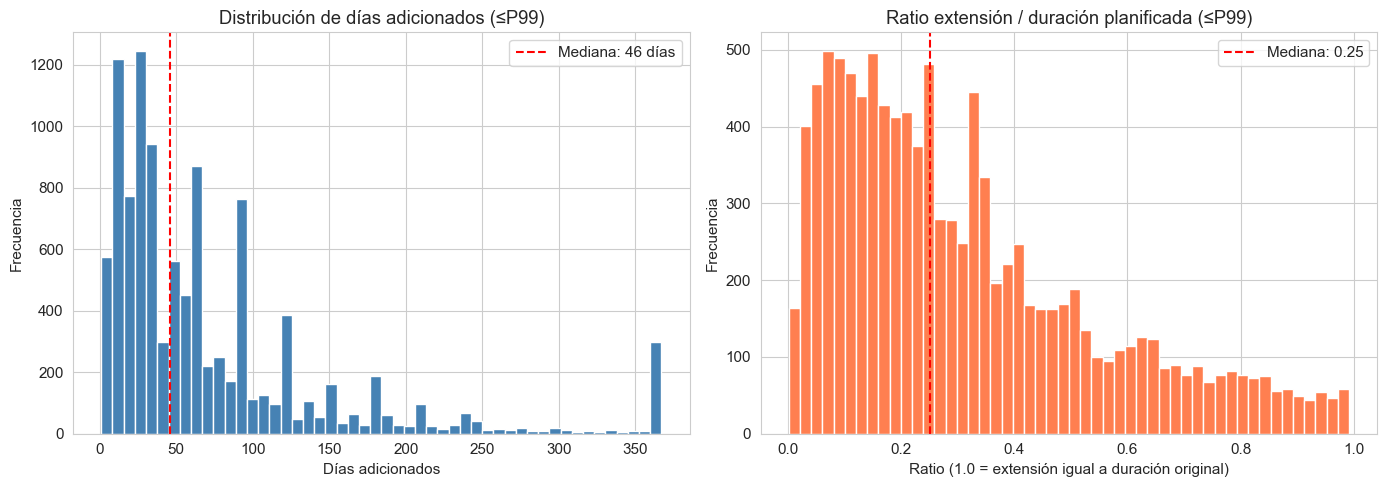

In [10]:
# Distribución de días adicionados
print('=== Días adicionados ===')
print(f'Contratos con extensión: {df["tiene_extension_dias"].sum():,} ({df["tiene_extension_dias"].mean()*100:.1f}%)')
print(f'Contratos sin extensión: {(~df["tiene_extension_dias"].astype(bool)).sum():,}')

ext = df[df['dias_adicionados'] > 0]['dias_adicionados']
print(f'\nEstadísticas (solo extensiones >0):')
print(ext.describe().round(1))
print(f'\nPercentiles:')
for p in [10, 25, 50, 75, 90, 95, 99]:
    print(f'  P{p}: {ext.quantile(p/100):.0f} días')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma de días adicionados (solo >0, recortado a P99)
p99 = ext.quantile(0.99)
axes[0].hist(ext[ext <= p99], bins=50, color='steelblue', edgecolor='white')
axes[0].axvline(ext.median(), color='red', linestyle='--', label=f'Mediana: {ext.median():.0f} días')
axes[0].set_title('Distribución de días adicionados (≤P99)')
axes[0].set_xlabel('Días adicionados')
axes[0].set_ylabel('Frecuencia')
axes[0].legend()

# Ratio extensión / duración planificada
ratio = df.loc[df['ratio_extension_duracion'].notna() & (df['ratio_extension_duracion'] > 0), 'ratio_extension_duracion']
ratio_clipped = ratio[ratio <= ratio.quantile(0.99)]
axes[1].hist(ratio_clipped, bins=50, color='coral', edgecolor='white')
axes[1].axvline(ratio.median(), color='red', linestyle='--', label=f'Mediana: {ratio.median():.2f}')
axes[1].set_title('Ratio extensión / duración planificada (≤P99)')
axes[1].set_xlabel('Ratio (1.0 = extensión igual a duración original)')
axes[1].set_ylabel('Frecuencia')
axes[1].legend()

plt.tight_layout()
plt.show()

### 7.1 Extensión de plazo por modalidad de contratación

Con la magnitud general de las extensiones ya caracterizada, la pregunta siguiente es si el riesgo de extensión depende de la modalidad de contratación bajo la cual se adjudicó el contrato (Licitación pública, Contratación directa, Mínima cuantía, etc.). Se agrupa por `modalidad_de_contratacion` y se calculan, para cada una, el porcentaje de contratos con extensión y la magnitud media/mediana de días adicionados, ordenando de mayor a menor porcentaje de incidencia para facilitar la lectura del ranking.

El resultado muestra un gradiente claro asociado a la complejidad/tamaño de la modalidad: `Licitación pública Obra Publica` encabeza con 33.5% de contratos con extensión (media de 28.8 días adicionados), seguida de modalidades de contratación directa y menor cuantía en el rango 21%-29%, mientras que `Mínima cuantía` —la modalidad reservada a los contratos de menor valor— tiene la incidencia más baja (12.0%) y también la magnitud media más pequeña (4.3 días). Esto es consistente con la intuición de que los contratos de obra más grandes y complejos (licitación pública) son también los que más se modifican en el tiempo.

### 7.2 Modificaciones por estado del contrato

Este segundo corte cruza las mismas variables de modificación (extensión, adición en valor, suspensión) contra `estado_contrato`, el campo que indica en qué fase de su ciclo de vida está el contrato dentro de SECOP II (Modificado, terminado, En ejecución, Cerrado, Suspendido, etc.). El propósito es distinto al de la modalidad: aquí se busca validar la consistencia interna de los datos y entender cómo se relacionan los estados administrativos con los indicadores de modificación ya calculados.

El hallazgo más importante, y en cierto modo una verificación de coherencia de los propios datos, es que el estado `Modificado` concentra 15.248 contratos y el 68.4% de ellos tiene extensión de plazo (mediana de 28 días) — es decir, el estado administrativo "Modificado" que asigna SECOP II está fuertemente alineado con los contadores de modificación construidos de forma independiente en la sección 3 a partir de la tabla de eventos de adiciones, lo cual es una señal de que la agregación hecha en este notebook es razonable. En contraste, contratos en estados como `terminado`, `En ejecución` o `Cerrado` muestran porcentajes de extensión residuales (0.1%-0.4%), como es de esperar si su modificación, de haber ocurrido, ya quedó reflejada en un cambio de estado a `Modificado` antes de llegar a su estado final. El estado `Suspendido` (1.181 contratos) muestra, coherentemente, la mayor tasa de suspensión (44.6%), otra validación cruzada entre el estado administrativo y los contadores derivados de eventos.

In [11]:
# Extensión por modalidad de contratación
ext_modalidad = df.groupby('modalidad_de_contratacion').agg(
    n_contratos=('id_contrato', 'count'),
    pct_con_extension=('tiene_extension_dias', 'mean'),
    dias_adicionados_mediana=('dias_adicionados', 'median'),
    dias_adicionados_media=('dias_adicionados', 'mean')
).sort_values('pct_con_extension', ascending=False)

ext_modalidad['pct_con_extension'] = (ext_modalidad['pct_con_extension'] * 100).round(1)
ext_modalidad['dias_adicionados_media'] = ext_modalidad['dias_adicionados_media'].round(1)

print('=== Extensiones por modalidad ===')
ext_modalidad

=== Extensiones por modalidad ===


,n_contratos,pct_con_extension,dias_adicionados_mediana,dias_adicionados_media
modalidad_de_contratacion,,,,
Licitación pública Obra Publica,8575,33.5,0.0,28.8
Seleccion Abreviada Menor Cuantia Sin Manifestacion Interes,297,29.3,0.0,25.1
Contratación directa,9981,23.6,0.0,29.4
Selección Abreviada de Menor Cuantía,12932,23.4,0.0,11.6
Contratación Directa (con ofertas),1541,21.1,0.0,19.8
Contratación régimen especial (con ofertas),1932,21.1,0.0,16.7
Contratación régimen especial,2905,13.8,0.0,7.9
Licitación pública,421,13.3,0.0,13.0
Mínima cuantía,9747,12.0,0.0,4.3


In [12]:
# Extensión por estado del contrato
ext_estado = df.groupby('estado_contrato').agg(
    n_contratos=('id_contrato', 'count'),
    pct_con_extension=('tiene_extension_dias', 'mean'),
    dias_mediana=('dias_adicionados', 'median'),
    pct_con_adicion_valor=('tiene_adicion_valor', 'mean'),
    pct_con_suspension=('tiene_suspension', 'mean')
).sort_values('n_contratos', ascending=False)

for col in ['pct_con_extension', 'pct_con_adicion_valor', 'pct_con_suspension']:
    ext_estado[col] = (ext_estado[col] * 100).round(1)

print('=== Modificaciones por estado del contrato ===')
ext_estado

=== Modificaciones por estado del contrato ===


,n_contratos,pct_con_extension,dias_mediana,pct_con_adicion_valor,pct_con_suspension
estado_contrato,,,,,
Modificado,15248,68.4,28.0,14.2,27.9
terminado,11259,0.4,0.0,13.9,19.9
En ejecución,9805,0.1,0.0,1.4,9.9
Cerrado,3072,0.2,0.0,15.9,6.2
Aprobado,2565,0.8,0.0,2.5,3.3
Borrador,2410,0.0,0.0,0.0,0.0
Cancelado,1681,0.0,0.0,0.1,0.1
Suspendido,1181,16.7,0.0,3.7,44.6
enviado Proveedor,650,0.0,0.0,0.0,0.0


## 8. Análisis: Adiciones en valor (dinero)

¿Qué contratos reciben adiciones en valor? ¿Cómo se relaciona con el valor original?

Esta sección se enfoca en `tiene_adicion_valor` / `n_adicion_valor`, el indicador de que un contrato recibió una adición presupuestal (más dinero sobre el valor originalmente pactado), que es conceptualmente distinto de la extensión de plazo analizada en la sección 7 (un contrato puede extenderse en tiempo sin que le adicionen valor, y viceversa, aunque como se ve en la sección 10 ambos eventos están correlacionados).

De los 48.331 contratos, 4.465 (9.2%) tuvieron al menos una adición en valor — una incidencia notablemente menor que la de extensión de plazo (22.1%), lo cual sugiere que ampliar el plazo de un contrato de obra es una modificación más común que ampliar su presupuesto. Entre los contratos que sí tuvieron adición de valor, la gran mayoría (3.642 de 4.465, el 81.6%) tuvo exactamente una adición; los casos de adiciones múltiples decrecen rápidamente (624 con dos, 148 con tres) hasta un caso extremo de 10 adiciones de valor sobre el mismo contrato.

La celda siguiente relaciona el valor del contrato original con la probabilidad de recibir estas modificaciones, usando `log10(valor_del_contrato)` en vez del valor crudo para el boxplot: dado que `valor_del_contrato` está fuertemente sesgado a la derecha (ver sección 6), graficarlo en escala logarítmica es indispensable para que los boxplots sean legibles y comparables. Las medianas confirman el patrón esperado — los contratos que reciben modificaciones son sistemáticamente más grandes en valor que los que no: la mediana de valor sube de \$199,9 millones (sin adición de valor) a \$345 millones (con adición de valor), y de \$157,9 millones (sin extensión) a \$521,9 millones (con extensión) — el salto es notablemente mayor para extensión de plazo que para adición de valor, reforzando la idea de que el tamaño del contrato está más asociado a que se le extienda el plazo que a que se le adicione presupuesto.

In [13]:
print('=== Adiciones en valor ===')
print(f'Contratos con adición en valor: {df["tiene_adicion_valor"].sum():,} ({df["tiene_adicion_valor"].mean()*100:.1f}%)')
print(f'Contratos sin adición en valor: {(~df["tiene_adicion_valor"].astype(bool)).sum():,}')

# Número de adiciones en valor por contrato
con_adicion = df[df['n_adicion_valor'] > 0]
print(f'\nDistribución de n_adicion_valor (solo >0):')
print(con_adicion['n_adicion_valor'].describe().round(1))
print(f'\nConteo:')
print(con_adicion['n_adicion_valor'].value_counts().sort_index().head(10))

=== Adiciones en valor ===
Contratos con adición en valor: 4,465 (9.2%)
Contratos sin adición en valor: 43,866

Distribución de n_adicion_valor (solo >0):
count    4465.0
mean        1.2
std         0.6
min         1.0
25%         1.0
50%         1.0
75%         1.0
max        10.0
Name: n_adicion_valor, dtype: float64

Conteo:
n_adicion_valor
1     3642
2      624
3      148
4       38
5       10
6        2
10       1
Name: count, dtype: int64


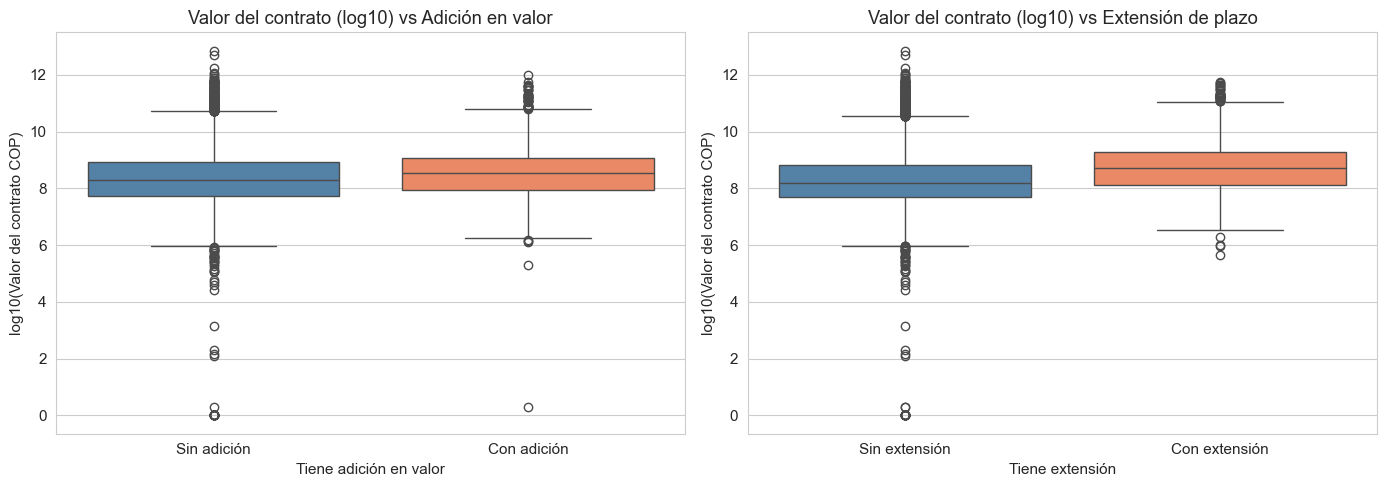

Mediana valor_del_contrato (COP):
  Sin adición valor: $199,921,893
  Con adición valor: $345,000,000
  Sin extensión:     $157,925,189
  Con extensión:     $521,940,758


In [14]:
# Relación entre valor del contrato y tener adición en valor
# Usar log del valor para mejor visualización
df['log_valor_contrato'] = np.log10(df['valor_del_contrato'].clip(lower=1))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot valor contrato vs tiene_adicion_valor
data_box = df[df['valor_del_contrato'] > 0]
sns.boxplot(data=data_box, x='tiene_adicion_valor', y='log_valor_contrato', ax=axes[0],
            palette=['steelblue', 'coral'])
axes[0].set_title('Valor del contrato (log10) vs Adición en valor')
axes[0].set_xlabel('Tiene adición en valor')
axes[0].set_ylabel('log10(Valor del contrato COP)')
axes[0].set_xticklabels(['Sin adición', 'Con adición'])

# Boxplot valor contrato vs tiene extensión
sns.boxplot(data=data_box, x='tiene_extension_dias', y='log_valor_contrato', ax=axes[1],
            palette=['steelblue', 'coral'])
axes[1].set_title('Valor del contrato (log10) vs Extensión de plazo')
axes[1].set_xlabel('Tiene extensión')
axes[1].set_ylabel('log10(Valor del contrato COP)')
axes[1].set_xticklabels(['Sin extensión', 'Con extensión'])

plt.tight_layout()
plt.show()

# Medianas numéricas
print('Mediana valor_del_contrato (COP):')
print(f'  Sin adición valor: ${data_box[data_box["tiene_adicion_valor"]==0]["valor_del_contrato"].median():,.0f}')
print(f'  Con adición valor: ${data_box[data_box["tiene_adicion_valor"]==1]["valor_del_contrato"].median():,.0f}')
print(f'  Sin extensión:     ${data_box[data_box["tiene_extension_dias"]==0]["valor_del_contrato"].median():,.0f}')
print(f'  Con extensión:     ${data_box[data_box["tiene_extension_dias"]==1]["valor_del_contrato"].median():,.0f}')

## 9. Análisis: Sobrecostos

Ratio entre valor pagado y valor del contrato original.

Esta sección retoma `sobrecosto_ratio`, el feature derivado en la sección 5 como `(valor_pagado - valor_del_contrato) / valor_del_contrato`, calculado solo cuando ambos valores son positivos. Es importante distinguir esta variable de `tiene_adicion_valor` (sección 8): `tiene_adicion_valor` mide si hubo una modificación *contractual* formal que aumentó el valor pactado, mientras que `sobrecosto_ratio` mide, a posteriori, la relación entre lo efectivamente *pagado* y lo *contratado*, sin importar si ese cambio pasó por una adición formal o no — son dos ángulos distintos y complementarios sobre el mismo fenómeno económico.

De los 48.331 contratos, solo 15.033 (31.1%) tienen este ratio calculable (los demás carecen de `valor_pagado` o `valor_del_contrato` positivo y quedan como `NaN`, tal como se explicó en la sección 6). Sobre esos 15.033, se construye una clasificación categórica con `pd.cut()` en siete bandas, desde "Subejecutado (>50%)" hasta "Sobrecosto extremo (>100%)". El resultado es, en cierto modo, contraintuitivo frente a lo que suele preocupar en el discurso público sobre contratación estatal (el "sobrecosto"): el patrón dominante en estos datos es la **sub-ejecución**, no el sobrecosto. El 66.7% de los contratos calculables (10.033) están en la banda "Sin sobrecosto (~0%)" (es decir, lo pagado prácticamente iguala lo contratado), un 23.7% (3.561) están "Subejecutados levemente" y un 9.5% (1.433) están "Subejecutados (>50%)" — es decir, se pagó menos de la mitad de lo contratado. Las bandas de sobrecosto real (leve, moderado, alto, extremo) suman en conjunto apenas 6 contratos de 15.033, prácticamente inexistentes en esta muestra. Esto tiene sentido si se recuerda que `valor_pagado` en SECOP II suele reflejar el corte de pagos hasta la fecha de extracción de los datos, no necesariamente el pago final del contrato — muchos contratos "subejecutados" pueden simplemente estar en curso.

La celda siguiente cruza este ratio con `tiene_adicion_valor` para ver si los contratos que sí recibieron una adición formal de valor muestran, en promedio, menor sub-ejecución que los que no la recibieron: la mediana es prácticamente igual en ambos grupos (≈0.0000), pero la media es levemente más negativa entre los contratos con adición de valor (-0.1124) que entre los que no la tuvieron (-0.1059) — una diferencia pequeña, señal de que la adición formal de valor no está necesariamente asociada con una mejor ejecución del pago frente al valor contratado.

In [15]:
# Sobrecosto solo donde ambos valores > 0
sc = df[df['sobrecosto_ratio'].notna()].copy()
print(f'Contratos con sobrecosto calculable: {len(sc):,} / {len(df):,}')
print(f'\nEstadísticas del ratio (pagado/contratado - 1):')
print(sc['sobrecosto_ratio'].describe().round(4))

# Clasificar sobrecostos
sc['categoria_sobrecosto'] = pd.cut(
    sc['sobrecosto_ratio'],
    bins=[-np.inf, -0.5, -0.01, 0.01, 0.1, 0.5, 1.0, np.inf],
    labels=['Subejecutado (>50%)', 'Subejecutado leve', 'Sin sobrecosto (~0%)',
            'Sobrecosto leve (1-10%)', 'Sobrecosto moderado (10-50%)',
            'Sobrecosto alto (50-100%)', 'Sobrecosto extremo (>100%)']
)

print('\nCategorías de sobrecosto:')
dist_sc = sc['categoria_sobrecosto'].value_counts()
for cat, n in dist_sc.items():
    print(f'  {cat}: {n:,} ({n/len(sc)*100:.1f}%)')

Contratos con sobrecosto calculable: 15,033 / 48,331

Estadísticas del ratio (pagado/contratado - 1):
count    15033.0000
mean        -0.1066
std          0.2157
min         -0.9986
25%         -0.1000
50%         -0.0000
75%          0.0000
max          0.6629
Name: sobrecosto_ratio, dtype: float64

Categorías de sobrecosto:
  Sin sobrecosto (~0%): 10,033 (66.7%)
  Subejecutado leve: 3,561 (23.7%)
  Subejecutado (>50%): 1,433 (9.5%)
  Sobrecosto leve (1-10%): 4 (0.0%)
  Sobrecosto moderado (10-50%): 1 (0.0%)
  Sobrecosto alto (50-100%): 1 (0.0%)
  Sobrecosto extremo (>100%): 0 (0.0%)


Sobrecosto ratio por adición en valor:


  Con adición: mediana=-0.0000, media=-0.1124
  Sin adición: mediana=-0.0000, media=-0.1059


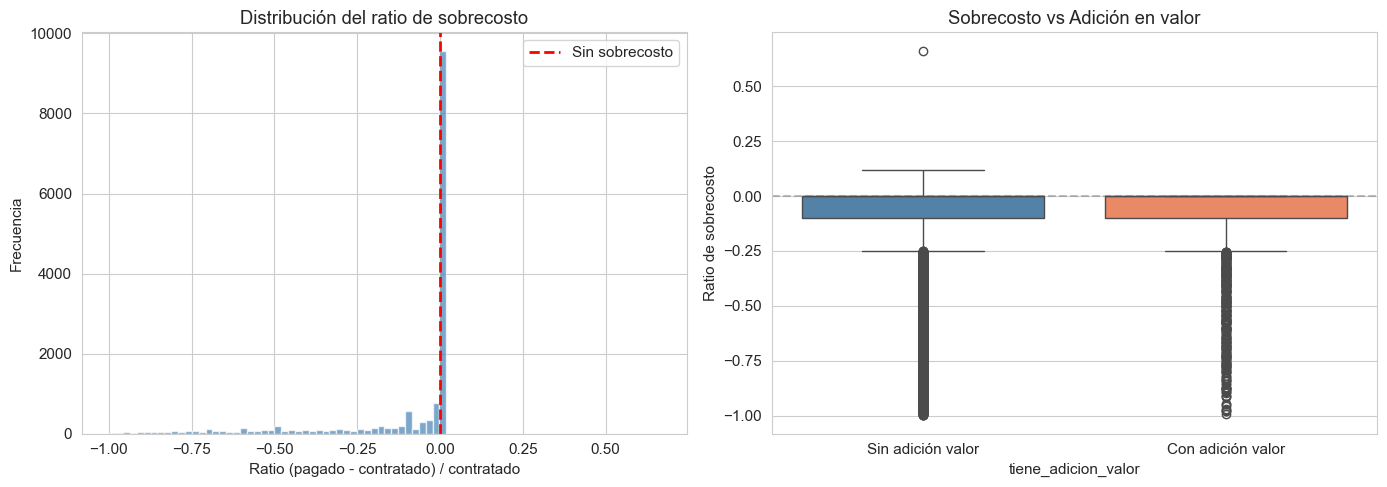

In [16]:
# Relación sobrecosto con adiciones en valor
sc_con_adicion = sc[sc['tiene_adicion_valor'] == 1]['sobrecosto_ratio']
sc_sin_adicion = sc[sc['tiene_adicion_valor'] == 0]['sobrecosto_ratio']

print('Sobrecosto ratio por adición en valor:')
print(f'  Con adición: mediana={sc_con_adicion.median():.4f}, media={sc_con_adicion.mean():.4f}')
print(f'  Sin adición: mediana={sc_sin_adicion.median():.4f}, media={sc_sin_adicion.mean():.4f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma de sobrecosto
sc_clip = sc[(sc['sobrecosto_ratio'] > -1) & (sc['sobrecosto_ratio'] < 2)]
axes[0].hist(sc_clip['sobrecosto_ratio'], bins=80, color='steelblue', edgecolor='white', alpha=0.7)
axes[0].axvline(0, color='red', linestyle='--', linewidth=2, label='Sin sobrecosto')
axes[0].set_title('Distribución del ratio de sobrecosto')
axes[0].set_xlabel('Ratio (pagado - contratado) / contratado')
axes[0].set_ylabel('Frecuencia')
axes[0].legend()

# Boxplot sobrecosto por adición en valor
sc_box = sc[(sc['sobrecosto_ratio'] > -1) & (sc['sobrecosto_ratio'] < 2)]
sns.boxplot(data=sc_box, x='tiene_adicion_valor', y='sobrecosto_ratio', ax=axes[1],
            palette=['steelblue', 'coral'])
axes[1].set_title('Sobrecosto vs Adición en valor')
axes[1].set_xticklabels(['Sin adición valor', 'Con adición valor'])
axes[1].set_ylabel('Ratio de sobrecosto')
axes[1].axhline(0, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## 10. Análisis: Suspensiones y cesiones

¿Qué tan frecuentes son? ¿Se relacionan con extensiones y adiciones?

Esta sección examina dos eventos contractuales adicionales: la suspensión temporal de la ejecución (`tiene_suspension`) y la cesión del contrato a otro proveedor (`tiene_cesion`), y en particular busca cuantificar si estos eventos tienden a co-ocurrir con las extensiones de plazo y las adiciones en valor ya estudiadas. La herramienta usada es la tabla cruzada (`pd.crosstab`), tanto en conteos absolutos como normalizada por fila, para poder leer directamente "de los contratos con suspensión, qué porcentaje también tiene extensión".

El resultado muestra una asociación clara entre suspensión y extensión: entre los 8.275 contratos con suspensión, el 44.9% también tiene extensión de plazo, frente a solo 17.4% entre los 40.056 contratos sin suspensión — es decir, un contrato suspendido tiene más del doble de probabilidad de terminar con una extensión de plazo, lo cual es coherente desde el punto de vista contractual: una suspensión casi siempre implica renegociar el cronograma una vez se reactiva la ejecución. La asociación con adición en valor es mucho más débil (11.9% con suspensión vs. 8.7% sin ella), sugiriendo que suspender un contrato afecta sobre todo su cronograma, no tanto su presupuesto.

Las cesiones, en contraste, son el evento contractual menos frecuente de todo el análisis: solo 496 contratos (1.0%) fueron cedidos a otro proveedor. De esos 496, el 39.9% (198) tiene también extensión de plazo y el 13.9% (69) tiene adición en valor — ambas proporciones más altas que el promedio general del dataset (22.1% y 9.2% respectivamente), lo que sugiere que la cesión de un contrato tiende a ocurrir en contratos que, de por sí, ya venían con un historial de modificaciones más activo, y no como un evento aislado.

In [17]:
# Tabla cruzada: suspensión vs extensión
print('=== Suspensión vs Extensión ===')
ct_susp_ext = pd.crosstab(df['tiene_suspension'], df['tiene_extension_dias'],
                           margins=True)
print('Conteos:')
print(ct_susp_ext)
print('\nPorcentajes por fila:')
ct_norm = pd.crosstab(df['tiene_suspension'], df['tiene_extension_dias'],
                       normalize='index').round(3) * 100
ct_norm.index = ['Sin suspensión', 'Con suspensión']
ct_norm.columns = ['Sin extensión %', 'Con extensión %']
print(ct_norm)

print('\n=== Suspensión vs Adición en valor ===')
ct_susp_val = pd.crosstab(df['tiene_suspension'], df['tiene_adicion_valor'],
                           normalize='index').round(3) * 100
ct_susp_val.index = ['Sin suspensión', 'Con suspensión']
ct_susp_val.columns = ['Sin adición valor %', 'Con adición valor %']
print(ct_susp_val)

print(f'\n=== Cesiones ===')
print(f'Contratos con cesión: {df["tiene_cesion"].sum():,} ({df["tiene_cesion"].mean()*100:.1f}%)')
cesion = df[df['tiene_cesion'] == 1]
print(f'De estos, tienen extensión: {cesion["tiene_extension_dias"].sum():,} ({cesion["tiene_extension_dias"].mean()*100:.1f}%)')
print(f'De estos, tienen adición valor: {cesion["tiene_adicion_valor"].sum():,} ({cesion["tiene_adicion_valor"].mean()*100:.1f}%)')

=== Suspensión vs Extensión ===
Conteos:
tiene_extension_dias      0      1    All
tiene_suspension                         
0                     33072   6984  40056
1                      4560   3715   8275
All                   37632  10699  48331

Porcentajes por fila:
                Sin extensión %  Con extensión %
Sin suspensión             82.6             17.4
Con suspensión             55.1             44.9

=== Suspensión vs Adición en valor ===
                Sin adición valor %  Con adición valor %
Sin suspensión                 91.3                  8.7
Con suspensión                 88.1                 11.9

=== Cesiones ===
Contratos con cesión: 496 (1.0%)
De estos, tienen extensión: 198 (39.9%)
De estos, tienen adición valor: 69 (13.9%)


## 11. Análisis: Co-ocurrencia de tipos de modificación

¿Los tipos de modificación ocurren juntos? ¿Qué combinaciones son frecuentes?

Las dos secciones anteriores (9 y 10) examinaron pares de variables de modificación una a la vez (adición de valor vs. extensión, suspensión vs. extensión, etc.). Esta sección generaliza esa idea calculando la matriz de correlación de Pearson entre las cinco variables binarias construidas en la sección 5 (`tiene_extension_dias`, `tiene_adicion_valor`, `tiene_suspension`, `tiene_cesion`, `tiene_conclusion`) y visualizándola como un mapa de calor (`sns.heatmap`) con escala divergente centrada en 0 (`cmap='RdBu_r', center=0`), de forma que las correlaciones positivas (tipos de modificación que tienden a co-ocurrir) y negativas (que tienden a excluirse) se distingan visualmente de un vistazo. Esta matriz formaliza, en un solo objeto, relaciones que ya se habían insinuado en la sección 10 (por ejemplo, la asociación positiva entre suspensión y extensión).

La segunda parte de la sección cambia de pregunta: en lugar de mirar pares de tipos, cuenta cuántos tipos *distintos* de modificación (`n_tipos_distintos`, construido en la sección 3 sobre la tabla de eventos original, con valores de 0 a 7 en este dataset) tiene cada contrato modificado. Sobre los 33.465 contratos con al menos una modificación, la distribución es: 12.802 contratos (38.2%) con un solo tipo de modificación, 9.615 (28.7%) con dos tipos, 5.762 (17.2%) con tres, 4.245 (12.7%) con cuatro, y una cola decreciente hasta apenas 2 contratos con los siete tipos distintos simultáneamente. Es decir, aunque el 69.2% de los contratos se modifica de alguna forma, la mayoría de esas modificaciones son de un tipo relativamente acotado (uno o dos tipos distintos concentran casi dos tercios de los contratos modificados); los historiales de modificación muy diversos y complejos (cuatro o más tipos distintos) son la minoría, aunque no despreciable (cerca de 5.286 contratos, el 15.8% de los modificados).

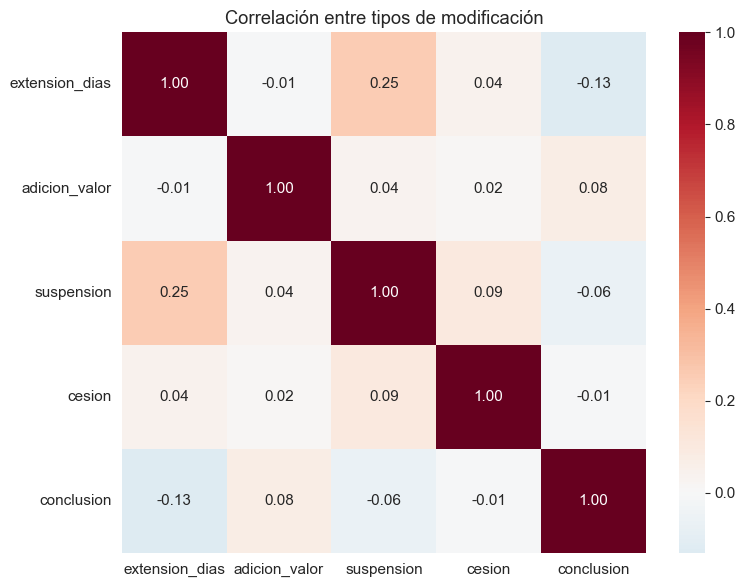

In [18]:
# Matriz de correlación entre tipos de modificación (binarias)
cols_binarias = ['tiene_extension_dias', 'tiene_adicion_valor', 'tiene_suspension',
                 'tiene_cesion', 'tiene_conclusion']

corr = df[cols_binarias].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax,
            xticklabels=[c.replace('tiene_', '') for c in cols_binarias],
            yticklabels=[c.replace('tiene_', '') for c in cols_binarias])
ax.set_title('Correlación entre tipos de modificación')
plt.tight_layout()
plt.show()

=== Diversidad de modificaciones ===
n_tipos_distintos
1    12802
2     9615
3     5762
4     4245
5      941
6       98
7        2
Name: count, dtype: int64


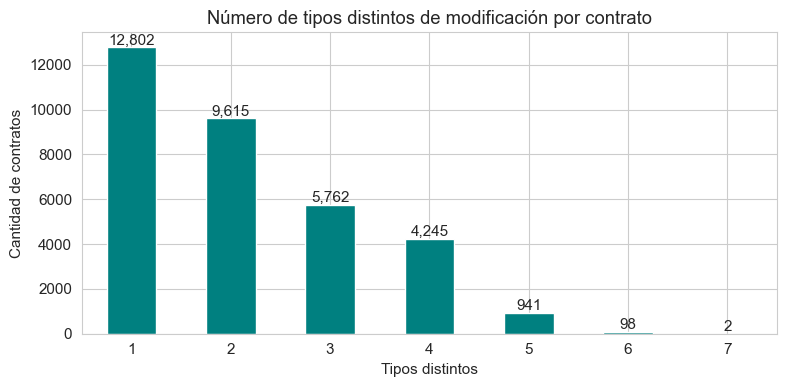

In [19]:
# Distribución del número de tipos distintos de modificación
print('=== Diversidad de modificaciones ===')
dist_tipos = df[df['n_tipos_distintos'] > 0]['n_tipos_distintos'].value_counts().sort_index()
print(dist_tipos)

fig, ax = plt.subplots(figsize=(8, 4))
dist_tipos.plot(kind='bar', ax=ax, color='teal', edgecolor='white')
ax.set_title('Número de tipos distintos de modificación por contrato')
ax.set_xlabel('Tipos distintos')
ax.set_ylabel('Cantidad de contratos')
ax.tick_params(axis='x', rotation=0)
for i, v in enumerate(dist_tipos.values):
    ax.text(i, v + 100, f'{v:,}', ha='center')
plt.tight_layout()
plt.show()

## 12. Análisis temporal: ¿cuándo ocurren las modificaciones?

Tiempo desde la firma del contrato hasta la primera modificación.

Hasta ahora el análisis ha sido transversal (cuántos contratos, de qué tipo, con qué magnitud); esta sección introduce la dimensión temporal usando dos features derivados en la sección 5 a partir de las fechas agregadas en la sección 3: `dias_hasta_primera_adicion` (tiempo entre la firma del contrato y su primer evento de modificación) y `ventana_adiciones_dias` (tiempo transcurrido entre la primera y la última modificación, es decir, cuánto duró "activo" el proceso de modificación de un contrato).

De los 33.465 contratos con adiciones, todos tienen fecha de primera adición, pero solo se puede calcular `dias_hasta_primera_adicion` para aquellos que también tienen `fecha_de_firma` válida; de esos, 13.398 contratos muestran un valor positivo (es decir, la modificación ocurrió estrictamente después de la firma, como es lógicamente esperado — valores negativos o cero indicarían inconsistencias de fecha en la fuente y se excluyen filtrando `> 0`). Entre esos 13.398, la mediana es de 91 días (aproximadamente 3 meses) desde la firma hasta la primera modificación, con una media más alta (199.1 días) por el efecto de una cola de contratos que tardan mucho más en modificarse por primera vez (percentil 75 en 231 días, máximo en 2.688 días, más de 7 años). El histograma se recorta al percentil 95 para mantener la legibilidad, igual que en la sección 7.

El segundo panel (`ventana_adiciones_dias`) mide cuánto tiempo transcurre entre la primera y la última modificación de un mismo contrato, una aproximación a cuánto tiempo estuvo un contrato "en proceso activo de modificación". Para contratos con una sola modificación esta ventana es 0 por construcción (primera y última fecha coinciden); los valores positivos analizados aquí corresponden a contratos con múltiples eventos de modificación espaciados en el tiempo, y su distribución (también recortada al percentil 95) permite estimar cuánto puede extenderse en el tiempo el proceso de renegociación de un contrato de obra pública.

Contratos con fecha primera adición y firma: 33,465
Con valores positivos: 13,398

Estadísticas (días hasta primera modificación):
count    13398.0
mean       199.1
std        306.6
min          1.0
25%         36.0
50%         91.0
75%        231.0
max       2688.0
Name: dias_hasta_primera_adicion, dtype: float64


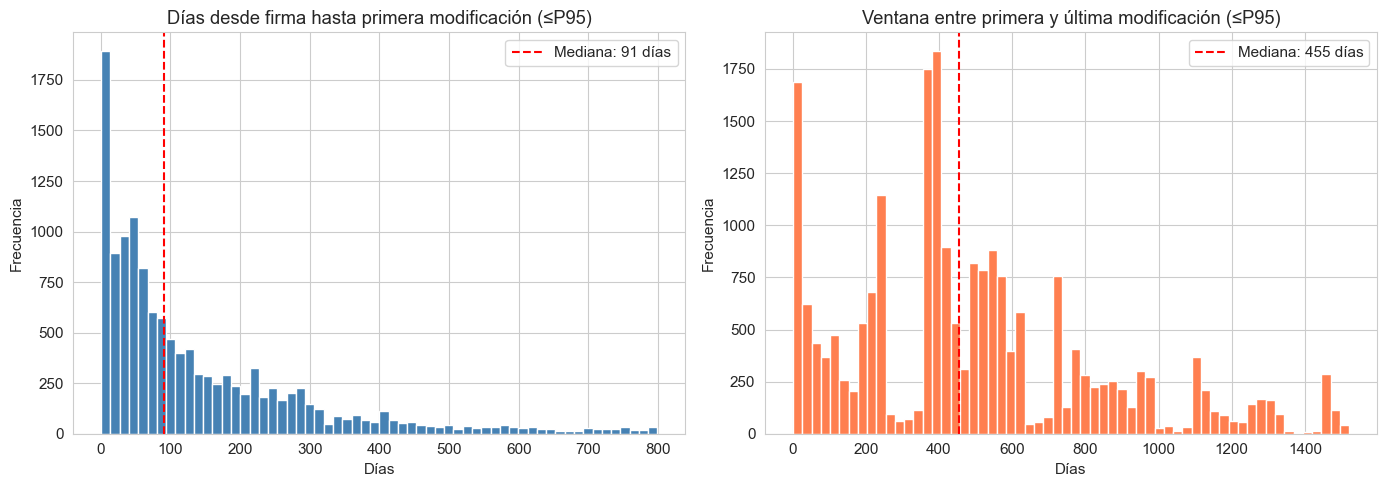

In [20]:
# Días hasta primera adición (desde firma)
dias_hasta = df['dias_hasta_primera_adicion'].dropna()
dias_hasta_pos = dias_hasta[dias_hasta > 0]

print(f'Contratos con fecha primera adición y firma: {len(dias_hasta):,}')
print(f'Con valores positivos: {len(dias_hasta_pos):,}')
print(f'\nEstadísticas (días hasta primera modificación):')
print(dias_hasta_pos.describe().round(1))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma
p95 = dias_hasta_pos.quantile(0.95)
axes[0].hist(dias_hasta_pos[dias_hasta_pos <= p95], bins=60, color='steelblue', edgecolor='white')
axes[0].axvline(dias_hasta_pos.median(), color='red', linestyle='--',
                label=f'Mediana: {dias_hasta_pos.median():.0f} días')
axes[0].set_title('Días desde firma hasta primera modificación (≤P95)')
axes[0].set_xlabel('Días')
axes[0].set_ylabel('Frecuencia')
axes[0].legend()

# Ventana de adiciones
ventana = df['ventana_adiciones_dias'].dropna()
ventana_pos = ventana[ventana > 0]
p95_v = ventana_pos.quantile(0.95)
axes[1].hist(ventana_pos[ventana_pos <= p95_v], bins=60, color='coral', edgecolor='white')
axes[1].axvline(ventana_pos.median(), color='red', linestyle='--',
                label=f'Mediana: {ventana_pos.median():.0f} días')
axes[1].set_title('Ventana entre primera y última modificación (≤P95)')
axes[1].set_xlabel('Días')
axes[1].set_ylabel('Frecuencia')
axes[1].legend()

plt.tight_layout()
plt.show()

## 13. Análisis: Geografía y modalidad

¿Dónde y bajo qué modalidades se concentran los problemas?

Esta sección desplaza el foco de "cuánto y cuándo se modifica un contrato" a "dónde y bajo qué modalidad". El primer bloque agrupa por `departamento`, pero antes filtra con `groupby('departamento').filter(lambda x: len(x) >= 50)` para excluir departamentos con muy pocos contratos de obra en el dataset — un umbral mínimo necesario porque, con conteos pequeños, un porcentaje de extensión (por ejemplo) puede oscilar violentamente por pura casualidad estadística y no reflejar un patrón real. Sobre los departamentos que sí superan ese umbral, se calculan el porcentaje de contratos con extensión, adición de valor y suspensión, además de la mediana de días adicionados, y se ordena de mayor a menor tasa de extensión.

El resultado muestra que los departamentos con mayor tasa de extensión no son necesariamente los de mayor volumen de contratación: Sucre (349 contratos, 32.4% con extensión) y Quindío (573 contratos, 32.1%) encabezan el ranking, por encima incluso de Distrito Capital de Bogotá, que pese a concentrar el mayor volumen de contratos de la muestra (14.338) tiene una tasa de extensión más moderada (23.6%). Esto sugiere que el riesgo de extensión de plazo no escala simplemente con el volumen de contratación de una región, sino que depende de factores propios de cada territorio (capacidad institucional, tipo de obras, condiciones geográficas, etc.) que están fuera del alcance descriptivo de este notebook, pero que quedan documentados como un hallazgo a profundizar en las fases analíticas posteriores.

El segundo bloque retoma la variable `modalidad_de_contratacion` (ya usada en la sección 7.1 para extensión) mostrando en una sola visualización de barras agrupadas los cuatro indicadores (extensión, adición de valor, suspensión, cesión) lado a lado para las siete modalidades más frecuentes, facilitando comparar de un vistazo si una modalidad es consistentemente más propensa a todos los tipos de modificación o solo a algunos.

In [21]:
# Top 15 departamentos con mayor tasa de extensión
depto_min = df.groupby('departamento').filter(lambda x: len(x) >= 50)
depto_stats = depto_min.groupby('departamento').agg(
    n_contratos=('id_contrato', 'count'),
    pct_extension=('tiene_extension_dias', 'mean'),
    pct_adicion_valor=('tiene_adicion_valor', 'mean'),
    pct_suspension=('tiene_suspension', 'mean'),
    dias_adicionados_mediana=('dias_adicionados', 'median')
).sort_values('pct_extension', ascending=False)

for col in ['pct_extension', 'pct_adicion_valor', 'pct_suspension']:
    depto_stats[col] = (depto_stats[col] * 100).round(1)

print('=== Top 15 departamentos por % de extensión (min 50 contratos) ===')
depto_stats.head(15)

=== Top 15 departamentos por % de extensión (min 50 contratos) ===


,n_contratos,pct_extension,pct_adicion_valor,pct_suspension,dias_adicionados_mediana
departamento,,,,,
Sucre,349,32.4,8.0,22.3,0.0
Quindío,573,32.1,8.6,17.5,0.0
Magdalena,648,29.9,4.5,38.3,0.0
Risaralda,855,29.4,6.7,22.1,0.0
Bolívar,1254,28.3,6.3,18.7,0.0
Caldas,1938,28.2,9.9,11.7,0.0
Cundinamarca,2412,27.3,7.3,18.4,0.0
Amazonas,144,27.1,8.3,29.2,0.0
Cauca,1328,26.9,4.7,19.8,0.0


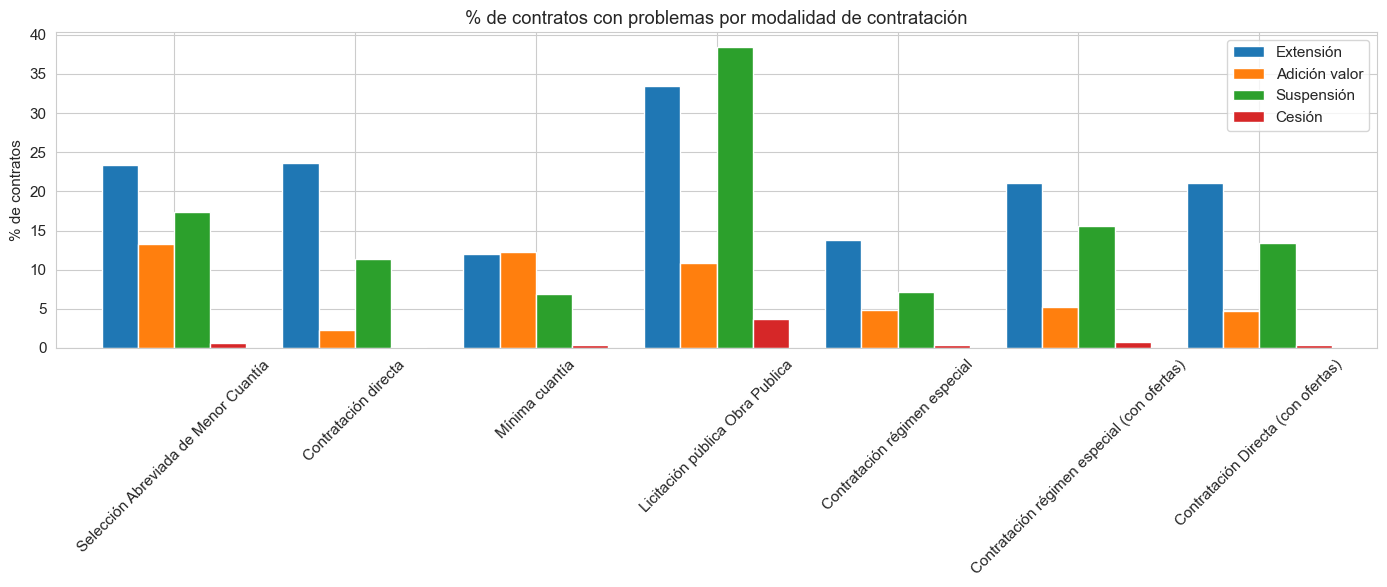

In [22]:
# Visualización: modalidad vs tipos de problema
modalidad_stats = df.groupby('modalidad_de_contratacion').agg(
    n=('id_contrato', 'count'),
    extension=('tiene_extension_dias', 'mean'),
    adicion_valor=('tiene_adicion_valor', 'mean'),
    suspension=('tiene_suspension', 'mean'),
    cesion=('tiene_cesion', 'mean')
).sort_values('n', ascending=False)

for col in ['extension', 'adicion_valor', 'suspension', 'cesion']:
    modalidad_stats[col] = (modalidad_stats[col] * 100).round(1)

# Plot grouped bar
modalidad_plot = modalidad_stats[['extension', 'adicion_valor', 'suspension', 'cesion']].head(7)
fig, ax = plt.subplots(figsize=(14, 6))
modalidad_plot.plot(kind='bar', ax=ax, width=0.8)
ax.set_title('% de contratos con problemas por modalidad de contratación')
ax.set_ylabel('% de contratos')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=45)
ax.legend(['Extensión', 'Adición valor', 'Suspensión', 'Cesión'], loc='upper right')
plt.tight_layout()
plt.show()

## 14. Análisis: Rangos de valor y comportamiento

¿Los contratos grandes tienen más problemas que los pequeños?

Esta sección retoma la relación entre el tamaño económico del contrato y su probabilidad de modificación, ya insinuada en la sección 8 mediante boxplots de valor en escala logarítmica, pero aquí se hace explícita mediante bandas discretas de valor (`pd.cut` con cortes en 50, 200, 1.000 y 10.000 millones COP: `<50M`, `50M-200M`, `200M-1B`, `1B-10B`, `>10B`), que es una forma más directa e interpretable de leer la tendencia que un scatter o boxplot continuo. Solo se consideran los contratos con `valor_del_contrato > 0` para evitar que contratos sin valor registrado (posible error de captura) distorsionen las bandas.

El patrón es monotónico y consistente en los tres indicadores de modificación: a medida que aumenta el rango de valor, aumenta la tasa de extensión (de 11.1% en `<50M` a 37.3% en `>10B`), la tasa de suspensión (de 7.4% a 31.8%) y, de forma menos marcada, la de adición de valor (de 6.5% a 10.2%-11.6%, con un leve techo alrededor de la banda `1B-10B`). Los días adicionados promedio también crecen de forma pronunciada con el valor: de 5.5 días en `<50M` a 44.8 días en `>10B`, casi un orden de magnitud de diferencia. En conjunto, esto confirma cuantitativamente lo que se observó cualitativamente en la sección 8: los contratos de obra de mayor cuantía son sistemáticamente más propensos a sufrir modificaciones de todo tipo, probablemente porque su mayor complejidad técnica y duración los expone a más imprevistos que ameritan renegociación contractual.

In [23]:
# Segmentar por rangos de valor
df_val = df[df['valor_del_contrato'] > 0].copy()
df_val['rango_valor'] = pd.cut(
    df_val['valor_del_contrato'],
    bins=[0, 50e6, 200e6, 1e9, 10e9, np.inf],
    labels=['<50M', '50M-200M', '200M-1B', '1B-10B', '>10B']
)

rango_stats = df_val.groupby('rango_valor', observed=True).agg(
    n_contratos=('id_contrato', 'count'),
    pct_extension=('tiene_extension_dias', 'mean'),
    pct_adicion_valor=('tiene_adicion_valor', 'mean'),
    pct_suspension=('tiene_suspension', 'mean'),
    dias_adicionados_media=('dias_adicionados', 'mean'),
    n_modif_media=('n_modificaciones_total', 'mean')
).round(3)

for col in ['pct_extension', 'pct_adicion_valor', 'pct_suspension']:
    rango_stats[col] = (rango_stats[col] * 100).round(1)

rango_stats['dias_adicionados_media'] = rango_stats['dias_adicionados_media'].round(1)
rango_stats['n_modif_media'] = rango_stats['n_modif_media'].round(1)

print('=== Comportamiento por rango de valor del contrato ===')
rango_stats

=== Comportamiento por rango de valor del contrato ===


,n_contratos,pct_extension,pct_adicion_valor,pct_suspension,dias_adicionados_media,n_modif_media
rango_valor,,,,,,
<50M,10800,11.1,6.5,7.4,5.5,1.4
50M-200M,12743,17.7,8.6,10.1,11.2,1.9
200M-1B,13051,26.2,10.9,20.1,19.4,3.4
1B-10B,8818,33.8,11.6,32.5,30.7,5.9
>10B,2223,37.3,10.2,31.8,44.8,7.4


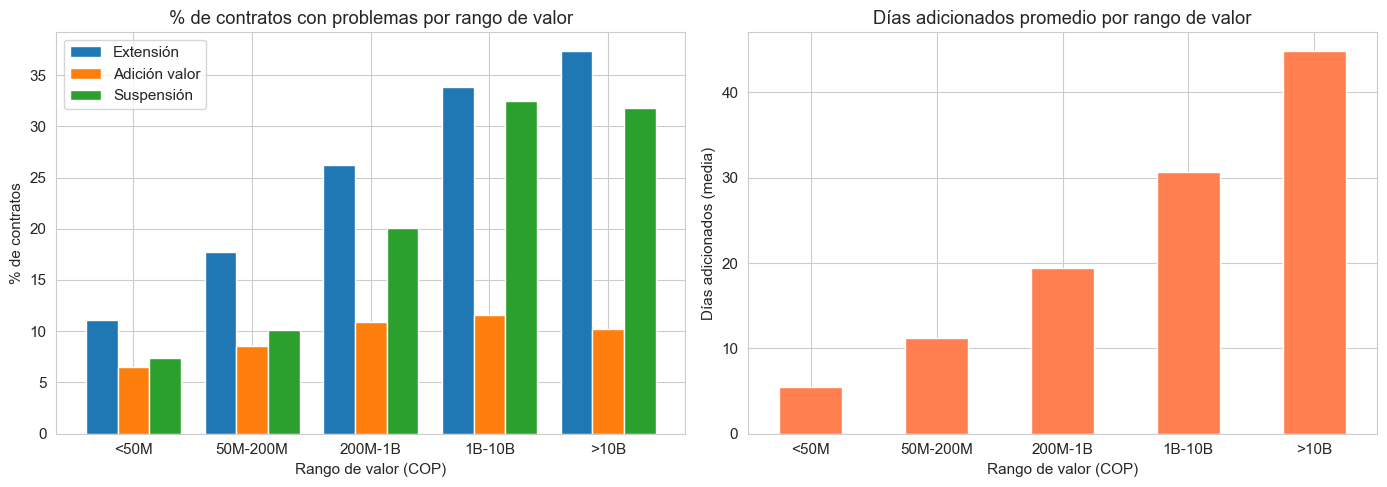

In [24]:
# Visualización
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# % de problemas por rango
rango_stats[['pct_extension', 'pct_adicion_valor', 'pct_suspension']].plot(
    kind='bar', ax=axes[0], width=0.8)
axes[0].set_title('% de contratos con problemas por rango de valor')
axes[0].set_ylabel('% de contratos')
axes[0].set_xlabel('Rango de valor (COP)')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(['Extensión', 'Adición valor', 'Suspensión'])

# Días adicionados promedio por rango
rango_stats['dias_adicionados_media'].plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Días adicionados promedio por rango de valor')
axes[1].set_ylabel('Días adicionados (media)')
axes[1].set_xlabel('Rango de valor (COP)')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

## 15. Análisis: Duración planificada y extensiones

Cierra el bloque de análisis relacional (secciones 7-15) examinando cómo se comportan las extensiones de plazo en función de la duración *originalmente planificada* del contrato, la variable `duracion_planificada_dias` construida en la sección 5. Al igual que en la sección 14, se trabaja con bandas discretas (`<1 mes`, `1-3 meses`, `3-6 meses`, `6-12 meses`, `1-2 años`, `>2 años`), filtrando previamente a duraciones entre 1 y 3.650 días (10 años) para excluir tanto los contratos con duración negativa o nula (la inconsistencia de datos ya señalada en la sección 6) como valores extremos poco representativos que distorsionarían las bandas.

El resultado muestra que, cuanto más larga es la duración planificada, mayor es tanto la probabilidad de extensión como su magnitud absoluta: la tasa de extensión sube de apenas 3.1% en contratos de menos de un mes a 51.2% en contratos de más de dos años, y los días adicionados promedio suben de 0.4 a 102.4 en el mismo rango — un patrón intuitivo, ya que los contratos más largos tienen más tiempo de ejecución durante el cual pueden surgir imprevistos que requieran extensión. Sin embargo, el ratio extensión/duración (`ratio_ext_dur_media`, la extensión expresada como proporción de la duración original) no crece de forma monótona: sube de 0.021 en `<1 mes` a un pico de 0.121 en `3-6 meses`, y luego se estabiliza alrededor de 0.09-0.105 para duraciones mayores — es decir, en términos *relativos* (no absolutos), los contratos de duración media (3 a 6 meses) son los que proporcionalmente más se extienden respecto a su plazo original, no los contratos más largos.

La celda siguiente visualiza esta misma relación como dispersión (`scatter`) entre duración planificada y días adicionados, limitando el rango a contratos con duración entre 1 y 2.000 días y extensión entre 1 y 1.000 días para mantener la nube de puntos legible, y superpone dos líneas de referencia (extensión = 100% y = 50% de la duración original) para ubicar visualmente qué proporción de contratos supera esos umbrales relativos. La correlación de Pearson calculada al final (0.521) confirma una asociación positiva moderada-fuerte entre ambas variables: los contratos más largos tienden, en efecto, a recibir extensiones más largas, aunque la relación está lejos de ser determinística (0.521 deja bastante variabilidad sin explicar solo por la duración planificada).

In [25]:
# Segmentar por duración planificada
df_dur = df[df['duracion_planificada_dias'].between(1, 3650)].copy()
df_dur['rango_duracion'] = pd.cut(
    df_dur['duracion_planificada_dias'],
    bins=[0, 30, 90, 180, 365, 730, 3650],
    labels=['<1 mes', '1-3 meses', '3-6 meses', '6-12 meses', '1-2 años', '>2 años']
)

dur_stats = df_dur.groupby('rango_duracion', observed=True).agg(
    n_contratos=('id_contrato', 'count'),
    pct_extension=('tiene_extension_dias', 'mean'),
    pct_adicion_valor=('tiene_adicion_valor', 'mean'),
    dias_adicionados_media=('dias_adicionados', 'mean'),
    ratio_ext_dur_media=('ratio_extension_duracion', 'mean')
).round(3)

for col in ['pct_extension', 'pct_adicion_valor']:
    dur_stats[col] = (dur_stats[col] * 100).round(1)
dur_stats['dias_adicionados_media'] = dur_stats['dias_adicionados_media'].round(1)
dur_stats['ratio_ext_dur_media'] = dur_stats['ratio_ext_dur_media'].round(3)

print('=== Comportamiento por duración planificada ===')
dur_stats

=== Comportamiento por duración planificada ===


,n_contratos,pct_extension,pct_adicion_valor,dias_adicionados_media,ratio_ext_dur_media
rango_duracion,,,,,
<1 mes,6462,3.1,7.3,0.4,0.021
1-3 meses,11022,16.2,10.8,4.8,0.073
3-6 meses,9569,31.5,12.4,15.6,0.121
6-12 meses,8914,30.8,10.2,23.3,0.090
1-2 años,4082,47.2,9.3,52.4,0.105
>2 años,1983,51.2,16.0,102.4,0.100


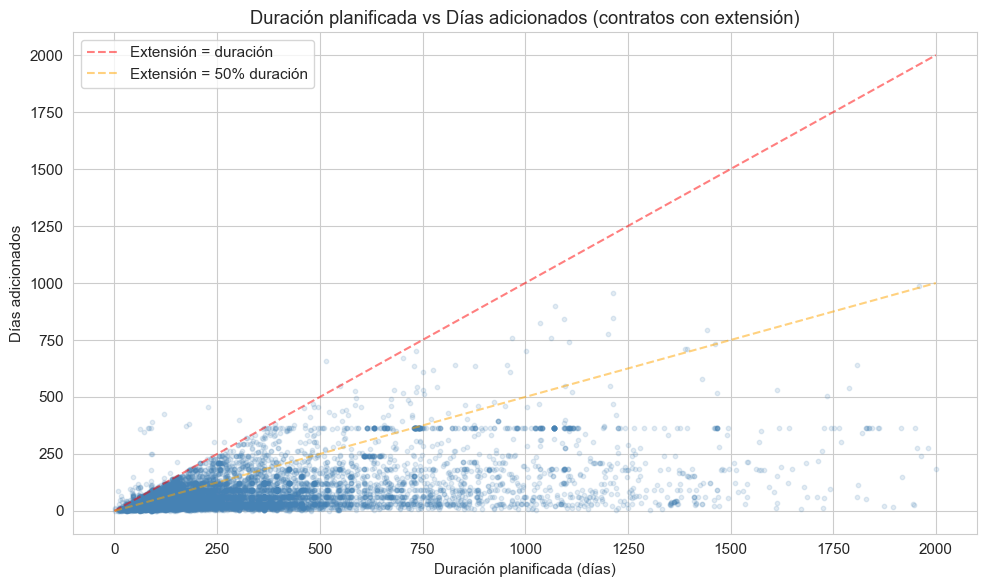

Correlación duración planificada vs días adicionados: 0.521


In [26]:
# Scatter: duración planificada vs días adicionados
scatter_data = df[(df['duracion_planificada_dias'].between(1, 2000)) & 
                  (df['dias_adicionados'] > 0) &
                  (df['dias_adicionados'] < 1000)].copy()

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(scatter_data['duracion_planificada_dias'], scatter_data['dias_adicionados'],
           alpha=0.15, s=10, color='steelblue')
# Línea de referencia: extensión = duración (100%)
ax.plot([0, 2000], [0, 2000], color='red', linestyle='--', alpha=0.5, label='Extensión = duración')
ax.plot([0, 2000], [0, 1000], color='orange', linestyle='--', alpha=0.5, label='Extensión = 50% duración')
ax.set_xlabel('Duración planificada (días)')
ax.set_ylabel('Días adicionados')
ax.set_title('Duración planificada vs Días adicionados (contratos con extensión)')
ax.legend()
plt.tight_layout()
plt.show()

# Correlación
corr_dur_ext = scatter_data['duracion_planificada_dias'].corr(scatter_data['dias_adicionados'])
print(f'Correlación duración planificada vs días adicionados: {corr_dur_ext:.3f}')

## 16. Resumen de hallazgos

Esta celda consolida en un solo bloque impreso las cifras centrales que se fueron calculando y explicando a lo largo de las secciones 4 a 15, a modo de resumen ejecutivo previo al guardado final de la tabla integrada en la sección 17. No introduce ningún cálculo nuevo: reutiliza las mismas columnas (`tiene_modificacion`, `tiene_extension_dias`, `tiene_adicion_valor`, `tiene_suspension`, `tiene_cesion`, `tiene_conclusion`, `dias_adicionados`, `sobrecosto_ratio` de la sub-tabla `sc` filtrada en la sección 9, y `duracion_planificada_dias`) para imprimir, de un vistazo, el panorama completo: 48.331 contratos de obra, de los cuales el 69.2% tuvo alguna modificación, encabezada por extensión de plazo (22.1%) y suspensión (17.1%), con una mediana de 46 días adicionados entre los contratos que se extendieron y una mediana de duración planificada de 115 días. Este resumen es, en la práctica, la síntesis narrativa que conecta el trabajo técnico de integración (secciones 1-6) con los hallazgos del análisis descriptivo (secciones 7-15), y sirve como referencia rápida para cualquier lector que solo quiera confirmar los números clave sin recorrer todo el notebook.

In [27]:
print('=' * 70)
print('RESUMEN — Integración Contratos + Adiciones')
print('=' * 70)
print(f'Contratos únicos de Obra:       {len(df):,}')
print(f'Con al menos una modificación:  {df["tiene_modificacion"].sum():,} ({df["tiene_modificacion"].mean()*100:.1f}%)')
print(f'Con extensión de plazo:         {df["tiene_extension_dias"].sum():,} ({df["tiene_extension_dias"].mean()*100:.1f}%)')
print(f'Con adición en valor:           {df["tiene_adicion_valor"].sum():,} ({df["tiene_adicion_valor"].mean()*100:.1f}%)')
print(f'Con suspensión:                 {df["tiene_suspension"].sum():,} ({df["tiene_suspension"].mean()*100:.1f}%)')
print(f'Con cesión:                     {df["tiene_cesion"].sum():,} ({df["tiene_cesion"].mean()*100:.1f}%)')
print(f'Con conclusión:                 {df["tiene_conclusion"].sum():,} ({df["tiene_conclusion"].mean()*100:.1f}%)')
print()
print(f'Días adicionados (mediana, solo >0): {df[df["dias_adicionados"]>0]["dias_adicionados"].median():.0f}')
print(f'Sobrecosto ratio (mediana, solo calculable): {sc["sobrecosto_ratio"].median():.4f}')
print(f'Duración planificada (mediana): {df["duracion_planificada_dias"].median():.0f} días')

RESUMEN — Integración Contratos + Adiciones
Contratos únicos de Obra:       48,331
Con al menos una modificación:  33,465 (69.2%)
Con extensión de plazo:         10,699 (22.1%)
Con adición en valor:           4,465 (9.2%)
Con suspensión:                 8,275 (17.1%)
Con cesión:                     496 (1.0%)
Con conclusión:                 5,087 (10.5%)

Días adicionados (mediana, solo >0): 46
Sobrecosto ratio (mediana, solo calculable): -0.0000
Duración planificada (mediana): 115 días


## 17. Guardado de tabla integrada

Última sección del notebook: persiste en disco, en formato Parquet, la tabla `df` que resultó de todo el proceso de limpieza, agregación, unión y construcción de features de las secciones 1 a 16 — 48.331 filas y, como confirma la celda de código, 111 columnas (el conteo sube de 110, visto en la sección 6, a 111 porque en el camino se agregó `log_valor_contrato` en la sección 8). Se guarda como `contratos_adiciones_obra.parquet` dentro de la misma carpeta compartida `DATA_DIR` de la que se leyeron los insumos en la sección 1, manteniendo la convención de formato Parquet de todo el proyecto (preserva tipos, es compacto: el archivo resultante pesa 16.1 MB pese a sus 48.331 × 111 celdas de datos).

La última parte de la celda calcula explícitamente la lista de columnas *nuevas* que este notebook agregó respecto a la tabla de contratos original (`df_contratos`, 87 columnas) — 24 columnas nuevas en total, que incluyen los 8 contadores por tipo de modificación y los 2 agregados de la sección 3, las 2 fechas de primera/última adición, las 6 variables binarias `tiene_*` y los 6 features numéricos derivados de la sección 5, más `log_valor_contrato` de la sección 8. Esta lista funciona como documentación explícita, embebida en el propio notebook, de exactamente qué aporta este proceso de integración sobre los datos crudos — información valiosa para cualquiera (el compañero de tesis, un lector externo, o el propio autor en el futuro) que necesite entender rápidamente el diccionario de datos de la tabla central del proyecto sin tener que releer todo el notebook.

Como se indicó en la introducción, este archivo Parquet es el punto de partida único y compartido a partir del cual se construyen, de forma completamente independiente, tanto el trabajo predictivo del compañero de tesis como el trabajo descriptivo de este documento (carpetas `analitica-descriptiva-andres/` y `eda-extendido-integral/`), cerrando así el ciclo de la fase de extracción y estructuración compartida del proyecto.

In [28]:
import os

output_path = DATA_DIR + 'contratos_adiciones_obra.parquet'
df.to_parquet(output_path, index=False)

size_mb = os.path.getsize(output_path) / (1024 * 1024)
print(f'Guardado: {output_path}')
print(f'Tamaño: {size_mb:.1f} MB')
print(f'Registros: {len(df):,}')
print(f'Columnas: {len(df.columns)}')
print(f'\nColumnas nuevas generadas:')
nuevas = [c for c in df.columns if c not in df_contratos.columns]
for c in nuevas:
    print(f'  - {c}')

Guardado: ../data/contratos_adiciones_obra.parquet
Tamaño: 16.1 MB
Registros: 48,331
Columnas: 111

Columnas nuevas generadas:
  - n_adicion_valor
  - n_cesion
  - n_conclusion
  - n_extension
  - n_modif_general
  - n_tipo_no_definido
  - n_reactivacion
  - n_suspension
  - n_modificaciones_total
  - n_tipos_distintos
  - fecha_primera_adicion
  - fecha_ultima_adicion
  - tiene_extension_dias
  - tiene_adicion_valor
  - tiene_suspension
  - tiene_cesion
  - tiene_conclusion
  - tiene_modificacion
  - sobrecosto_ratio
  - duracion_planificada_dias
  - ratio_extension_duracion
  - dias_hasta_primera_adicion
  - ventana_adiciones_dias
  - log_valor_contrato


## Anexo — Explicación de este notebook en lenguaje no técnico

*Fuente: `trabajo-de-grado-final/notebooks-explicados/01-extraccion-y-estructuracion-compartida/05_integracion_contratos_adiciones.md`, preparado para el Anexo A del trabajo de grado.*

### Explicación técnica paso a paso

1. **Deduplicación final de contratos.** Se parte de los 51.353 contratos del notebook 01 y se eliminan 3.022 registros duplicados por `id_contrato`, conservando en cada caso el registro más reciente (el que tiene la fecha de última actualización más nueva, bajo el supuesto de que refleja el estado más al día del contrato). El resultado es 48.331 contratos únicos.

2. **Agregación de adiciones por contrato.** La tabla de adiciones del notebook 03 está a nivel de evento (una fila por modificación), no a nivel de contrato. Aquí se hace un `groupby` por el identificador del contrato, construyendo, para cada uno, contadores: cuántas extensiones de plazo tuvo, cuántas adiciones de valor, cuántas suspensiones, cuántas cesiones, cuántas conclusiones anticipadas, y un total de modificaciones sumando todos los tipos. Este paso convierte 249.037 filas de eventos individuales en columnas resumidas sobre 48.331 filas de contratos.

3. **Eliminación de duplicados en adiciones antes de agregar.** Antes de sumar, se eliminan las 96.942 filas 100% idénticas detectadas en el notebook 03, para no contar dos veces el mismo evento y así inflar artificialmente los contadores de modificaciones (por ejemplo, que un contrato aparezca con 6 extensiones de plazo cuando en realidad tuvo 3, solo porque cada una estaba duplicada en el sistema origen).

4. **Unión (join) de las tablas.** Se cruza la tabla de contratos (ya deduplicada) con la tabla de adiciones agregadas, usando `id_contrato` como llave; y por separado se deja preparada la unión con procesos (usando la llave corregida `id_del_portafolio` del notebook 02) y con proveedores (usando el código de proveedor del notebook 04). El resultado de este proceso de unión es una única tabla ancha, con 48.331 filas (una por contrato) y más de cien columnas que combinan datos de la firma del contrato, sus modificaciones agregadas, y campos de referencia hacia proceso y proveedor.

5. **Verificación de integridad.** Se comprueba que la unión no haya cambiado el número de filas (debe seguir siendo 48.331; si aumentara, significaría que alguna llave tiene duplicados sin resolver y se estaría multiplicando información por error) y que los contadores de modificaciones agregados coincidan, en una muestra de verificación manual, con lo que se ve directamente en la tabla de eventos sin agregar.

6. **Persistencia del archivo central.** Esta tabla integrada de 48.331 contratos se guarda en formato Parquet y se convierte en el punto de partida único a partir del cual se construyen, de forma completamente separada, tanto el trabajo predictivo del compañero como el trabajo descriptivo de este documento (`analitica-descriptiva-andres/` y `eda-extendido-integral/`).

### Conclusión

**Qué se hizo, en palabras simples**

Hasta aquí se tenían varias tablas por separado: contratos, adiciones, procesos, proveedores. Este notebook las juntó en una sola tabla, donde cada fila es un contrato de obra pública con toda su información resumida: cuántas veces se le hicieron adiciones, si tuvo suspensiones, si terminó antes de tiempo, cuánto dinero se le agregó, etc.

El resultado es el archivo central de todo el proyecto: 48.331 contratos únicos de obra pública, con más de cien columnas de información cada uno.

**Por qué importa**

Es la tabla que tanto este trabajo como el del compañero de tesis usan como punto de partida — cada uno construye su propio análisis a partir de aquí, sin depender del código del otro.